# **1. Imports**

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib

from scipy                import stats
from sklearn.metrics      import (
    roc_curve, auc, precision_recall_curve,
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

# **2. Carga de Datos**

## 2a. Modelos propios (probabilidades predichas)

In [31]:
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/Datasets/Final Project/Processed/'

y_test        = pd.read_parquet(f'{BASE}y_test.parquet')['Is Laundering']
proba_nb      = pd.read_parquet(f'{BASE}y_proba_nb.parquet')['y_proba_nb'].values
proba_dt      = pd.read_parquet(f'{BASE}y_proba_dt.parquet')['y_proba_dt'].values
proba_lr      = pd.read_parquet(f'{BASE}y_proba_lr.parquet')['y_proba_lr'].values
proba_l1_l2   = pd.read_parquet(f'{BASE}y_proba_lr_l1_l2.parquet')['y_proba_lr_l1_l2'].values
proba_xgb     = pd.read_parquet(f'{BASE}y_proba_xgb.parquet')['y_proba_xgb'].values
proba_svm     = pd.read_parquet(f'{BASE}y_proba_svm.parquet')['y_proba_svm'].values
proba_cascade = pd.read_parquet(f'{BASE}y_proba_cascade_cv.parquet')['y_proba_cascade_cv'].values

y_true = y_test.values

MODELS = {
    'Naive Bayes'    : proba_nb,
    'Decision Tree'  : proba_dt,
    'Ridge (LR)'     : proba_lr,
    'LogReg (L1+L2)' : proba_l1_l2,
    'XGBoost'        : proba_xgb,
    'SVM'            : proba_svm,
    'CascadeBoost'   : proba_cascade,
}

COLORS = {
    'Naive Bayes'    : '#E41A1C',
    'Decision Tree'  : '#F781BF',
    'Ridge (LR)'     : '#377EB8',
    'LogReg (L1+L2)' : '#A65628',
    'XGBoost'        : '#4DAF4A',
    'SVM'            : '#984EA3',
    'CascadeBoost'   : '#FF7F00',
}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2b. Resultados reportados en el paper (Egressy et al., AAAI 2024)

In [32]:
# Minority-class F1 (%) — Tabla 2 del paper, columna AML Small HI
# Formato: {'F1': media, 'F1_std': desviacion_estandar}
# Fuente: Egressy et al. "Provably Powerful Graph Neural Networks
#         for Directed Multigraphs", AAAI 2024. arXiv:2306.11586v3
PAPER_RESULTS = {
    # --- Baselines tree-based con graph features ---
    'LightGBM+GFs'   : {'F1': 62.86, 'F1_std': 0.25,  'group': 'Tree-based'},
    'XGBoost+GFs'    : {'F1': 63.23, 'F1_std': 0.17,  'group': 'Tree-based'},
    # --- GNNs base sin adaptaciones ---
    'GIN'            : {'F1': 28.70, 'F1_std': 1.13,  'group': 'GNN base'},
    'PNA'            : {'F1': 56.77, 'F1_std': 2.41,  'group': 'GNN base'},
    'GIN+EU'         : {'F1': 47.73, 'F1_std': 7.86,  'group': 'GNN base'},
    'R-GCN'          : {'F1': 41.78, 'F1_std': 0.48,  'group': 'GNN base'},
    # --- GNNs con adaptaciones individuales ---
    'GIN+EgoIDs'     : {'F1': 39.65, 'F1_std': 4.73,  'group': 'GNN+adapt.'},
    'GIN+Ports'      : {'F1': 54.85, 'F1_std': 0.89,  'group': 'GNN+adapt.'},
    'GIN+ReverseMP'  : {'F1': 46.79, 'F1_std': 4.97,  'group': 'GNN+adapt.'},
    # --- GNNs con todas las adaptaciones (Multi-GNNs) ---
    'Multi-GIN'      : {'F1': 57.15, 'F1_std': 4.99,  'group': 'Multi-GNN'},
    'Multi-GIN+EU'   : {'F1': 64.79, 'F1_std': 1.22,  'group': 'Multi-GNN'},
    'Multi-PNA'      : {'F1': 64.59, 'F1_std': 3.60,  'group': 'Multi-GNN'},
    'Multi-PNA+EU'   : {'F1': 68.16, 'F1_std': 2.65,  'group': 'Multi-GNN'},  # SOTA
}

paper_df = pd.DataFrame(PAPER_RESULTS).T
paper_df.index.name = 'Modelo'
paper_df['F1']     = paper_df['F1'].astype(float)
paper_df['F1_std'] = paper_df['F1_std'].astype(float)

# Colores por grupo para los graficos del paper
GROUP_COLORS = {
    'Tree-based' : '#2ca02c',
    'GNN base'   : '#aec7e8',
    'GNN+adapt.' : '#ffbb78',
    'Multi-GNN'  : '#1f77b4',
}

print('Resultados del paper cargados correctamente.')
print(paper_df[['F1','F1_std','group']].to_string())

Resultados del paper cargados correctamente.
                  F1  F1_std       group
Modelo                                  
LightGBM+GFs   62.86    0.25  Tree-based
XGBoost+GFs    63.23    0.17  Tree-based
GIN            28.70    1.13    GNN base
PNA            56.77    2.41    GNN base
GIN+EU         47.73    7.86    GNN base
R-GCN          41.78    0.48    GNN base
GIN+EgoIDs     39.65    4.73  GNN+adapt.
GIN+Ports      54.85    0.89  GNN+adapt.
GIN+ReverseMP  46.79    4.97  GNN+adapt.
Multi-GIN      57.15    4.99   Multi-GNN
Multi-GIN+EU   64.79    1.22   Multi-GNN
Multi-PNA      64.59    3.60   Multi-GNN
Multi-PNA+EU   68.16    2.65   Multi-GNN


# **3. Funciones Auxiliares**

In [33]:
def compute_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
    return {
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred, zero_division=0),
        'Recall'    : recall_score(y_true, y_pred, zero_division=0),
        'F1'        : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_true, y_proba),
        'PR-AUC'    : auc(rec_c, prec_c),
    }


def delong_test(y_true, proba_a, proba_b):
    """
    Test de DeLong para comparar dos AUCs.
    Retorna (auc_a, auc_b, diferencia, z_stat, p_value).
    Implementacion basada en Sun & Xu (2014).
    """
    def _placement_values(y_true, proba):
        pos = proba[y_true == 1]
        neg = proba[y_true == 0]
        V10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
        V01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
        return V10, V01

    n1 = np.sum(y_true == 1)
    n0 = np.sum(y_true == 0)

    V10_a, V01_a = _placement_values(y_true, proba_a)
    V10_b, V01_b = _placement_values(y_true, proba_b)

    auc_a = V10_a.mean()
    auc_b = V10_b.mean()

    S10 = np.cov(V10_a, V10_b) / n1
    S01 = np.cov(V01_a, V01_b) / n0

    var_diff = (S10[0,0] + S01[0,0]
                - 2*S10[0,1] - 2*S01[0,1]
                + S10[1,1] + S01[1,1])

    if var_diff <= 0:
        return auc_a, auc_b, auc_a - auc_b, np.nan, np.nan

    z = (auc_a - auc_b) / np.sqrt(var_diff)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, auc_a - auc_b, z, p


def bootstrap_ci(y_true, y_proba, metric_fn, n_bootstrap=1000, ci=0.95, seed=42):
    """
    Estima IC y desviación estándar por bootstrap para una metrica dada.
    metric_fn debe aceptar (y_true, y_proba) y retornar un escalar.
    """
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_proba[idx]))

    alpha = (1 - ci) / 2
    return (
        np.mean(scores),
        np.std(scores),
        np.percentile(scores, alpha * 100),
        np.percentile(scores, (1 - alpha) * 100),
    )


# **4. Tabla Comparativa — Modelos Propios**

                Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Modelo                                                              
Naive Bayes       0.9020     0.0160  0.8999  0.0315   0.9445  0.0496
Decision Tree     0.9984     0.6985  0.1546  0.2532   0.6900  0.2277
Ridge (LR)        0.9529     0.0331  0.9093  0.0640   0.9829  0.2883
LogReg (L1+L2)    0.9529     0.0331  0.9093  0.0640   0.9829  0.2883
XGBoost           0.9986     0.8646  0.2380  0.3733   0.9698  0.4442
SVM               0.9715     0.0524  0.8854  0.0990   0.9771  0.1829
CascadeBoost      0.9990     0.8651  0.5028  0.6359   0.9515  0.6353


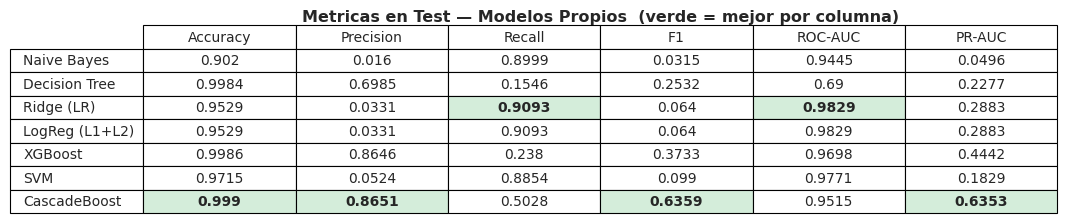

In [34]:
rows = []
for name, proba in MODELS.items():
    m = compute_metrics(y_true, proba)
    m['Modelo'] = name
    rows.append(m)

metrics_df = (
    pd.DataFrame(rows)
    .set_index('Modelo')
    [['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']]
)

print(metrics_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.axis('off')
tbl = ax.table(
    cellText  = metrics_df.round(4).values,
    rowLabels = metrics_df.index.tolist(),
    colLabels = metrics_df.columns.tolist(),
    cellLoc   = 'center',
    loc       = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

for j, col in enumerate(metrics_df.columns):
    best_row = metrics_df[col].idxmax()
    best_i   = metrics_df.index.tolist().index(best_row)
    tbl[best_i + 1, j].set_facecolor('#d4edda')
    tbl[best_i + 1, j].set_text_props(fontweight='bold')

plt.title('Metricas en Test — Modelos Propios  (verde = mejor por columna)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

La tabla revela un claro trade-off entre los modelos: Ridge y LogReg dominan en recall (0.909) y ROC-AUC (0.983) pero con precisión ínfima (~0.033), lo que significa que alertan casi todo indiscriminadamente y son inútiles en producción. CascadeBoost es el único modelo que equilibra precisión alta (0.865) con un recall aceptable (0.503), resultando en el mejor F1 (0.636) y PR-AUC (0.635) por amplio margen, las dos métricas más relevantes bajo desbalance extremo. XGBoost queda en un punto intermedio pero sin alcanzar el balance de CascadeBoost, mientras que Naive Bayes y SVM sacrifican precisión sin ganar suficiente recall para justificarlo.

# **5. Tabla Comparativa — Modelos del Paper**

Minority-class F1 (%) — AML Small HI  |  Egressy et al., AAAI 2024
                    Grupo      F1 ± Std
Modelo                                 
LightGBM+GFs   Tree-based  62.86 ± 0.25
XGBoost+GFs    Tree-based  63.23 ± 0.17
GIN              GNN base  28.70 ± 1.13
PNA              GNN base  56.77 ± 2.41
GIN+EU           GNN base  47.73 ± 7.86
R-GCN            GNN base  41.78 ± 0.48
GIN+EgoIDs     GNN+adapt.  39.65 ± 4.73
GIN+Ports      GNN+adapt.  54.85 ± 0.89
GIN+ReverseMP  GNN+adapt.  46.79 ± 4.97
Multi-GIN       Multi-GNN  57.15 ± 4.99
Multi-GIN+EU    Multi-GNN  64.79 ± 1.22
Multi-PNA       Multi-GNN  64.59 ± 3.60
Multi-PNA+EU    Multi-GNN  68.16 ± 2.65

SOTA del paper: Multi-PNA+EU  →  68.16 ± 2.65 %


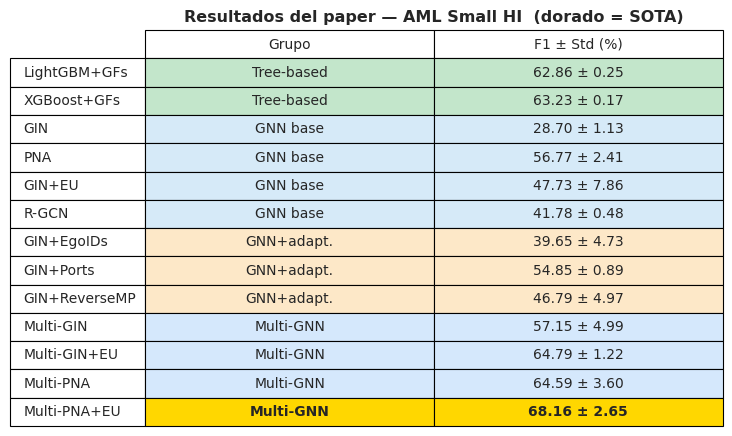

In [35]:
# Nota: la metrica es minority-class F1 (%) sobre AML Small HI.
# Los valores son media ± std sobre 5 runs (reportados en Tabla 2).
display_paper = paper_df[['group','F1','F1_std']].copy()
display_paper.columns = ['Grupo', 'F1 (%)', 'Std (%)']
display_paper['F1 ± Std'] = (
    display_paper['F1 (%)'].map('{:.2f}'.format)
    + ' ± '
    + display_paper['Std (%)'].map('{:.2f}'.format)
)

print('Minority-class F1 (%) — AML Small HI  |  Egressy et al., AAAI 2024')
print('=' * 55)
print(display_paper[['Grupo', 'F1 ± Std']].to_string())
print()
print('SOTA del paper: Multi-PNA+EU  →  68.16 ± 2.65 %')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axis('off')
tbl2 = ax.table(
    cellText  = display_paper[['Grupo','F1 ± Std']].values,
    rowLabels = display_paper.index.tolist(),
    colLabels = ['Grupo', 'F1 ± Std (%)'],
    cellLoc   = 'center',
    loc       = 'center',
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(10)
tbl2.scale(1.3, 1.55)

# Colorear por grupo
group_palette = {
    'Tree-based' : '#c3e6cb',
    'GNN base'   : '#d6eaf8',
    'GNN+adapt.' : '#fde8c8',
    'Multi-GNN'  : '#d5e8fc',
}
for i, (idx, row) in enumerate(display_paper.iterrows()):
    color = group_palette.get(row['Grupo'], '#ffffff')
    tbl2[i+1, 0].set_facecolor(color)
    tbl2[i+1, 1].set_facecolor(color)

# Resaltar SOTA
sota_i = display_paper.index.tolist().index('Multi-PNA+EU')
for j in range(2):
    tbl2[sota_i+1, j].set_facecolor('#ffd700')
    tbl2[sota_i+1, j].set_text_props(fontweight='bold')

plt.title('Resultados del paper — AML Small HI  (dorado = SOTA)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Los resultados del paper muestran que las GNNs base sin adaptaciones (GIN, R-GCN) son sorprendentemente débiles (F1 28–57%), mientras que los modelos tree-based con graph features (LightGBM+GFs, XGBoost+GFs) alcanzan ~63% con baja varianza, siendo competitivos y estables. Las adaptaciones individuales a GNNs (Ports, ReverseMP) mejoran parcialmente pero no superan a los tree-based, y solo las Multi-GNNs con todas las adaptaciones combinadas logran superar esa barrera, con Multi-PNA+EU como SOTA en 68.16% ± 2.65. Esto sugiere que la estructura del grafo solo aporta valor real cuando se explotan simultáneamente la direccionalidad, los puertos y la agregación multiescala, de lo contrario un buen modelo tabular lo iguala o supera.

# **6. Tabla Unificada de F1**

        Modelo Origen  F1 (%)                     Ref.
  Multi-PNA+EU  Paper   68.16 Egressy et al. AAAI 2024
  Multi-GIN+EU  Paper   64.79 Egressy et al. AAAI 2024
     Multi-PNA  Paper   64.59 Egressy et al. AAAI 2024
  CascadeBoost Propio   63.59                        —
   XGBoost+GFs  Paper   63.23 Egressy et al. AAAI 2024
  LightGBM+GFs  Paper   62.86 Egressy et al. AAAI 2024
     Multi-GIN  Paper   57.15 Egressy et al. AAAI 2024
           PNA  Paper   56.77 Egressy et al. AAAI 2024
     GIN+Ports  Paper   54.85 Egressy et al. AAAI 2024
        GIN+EU  Paper   47.73 Egressy et al. AAAI 2024
 GIN+ReverseMP  Paper   46.79 Egressy et al. AAAI 2024
         R-GCN  Paper   41.78 Egressy et al. AAAI 2024
    GIN+EgoIDs  Paper   39.65 Egressy et al. AAAI 2024
       XGBoost Propio   37.33                        —
           GIN  Paper   28.70 Egressy et al. AAAI 2024
 Decision Tree Propio   25.32                        —
           SVM Propio    9.90                        —
    Ridge 

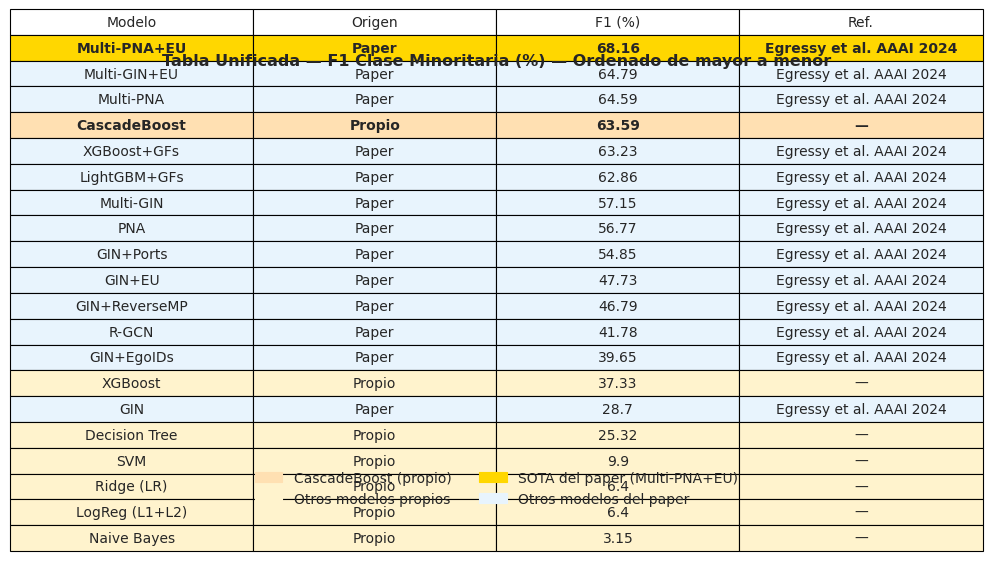

In [36]:
# Construir tabla unificada con F1 en la misma escala (%)
# Utilizamos F1 directo para que sea comparable y omitimos el bootstrap aquí
f1_fn = lambda yt, yp: f1_score(yt, (yp >= 0.5).astype(int), zero_division=0)

unified_rows = []

# ── Modelos propios
for name, proba in MODELS.items():
    raw_f1 = f1_fn(y_true, proba)
    unified_rows.append({
        'Modelo'   : name,
        'Origen'   : 'Propio',
        'F1 (%)'   : round(raw_f1 * 100, 2),
        'Ref.'     : '—',
    })

# ── Modelos del paper
for name, vals in PAPER_RESULTS.items():
    unified_rows.append({
        'Modelo'   : name,
        'Origen'   : 'Paper',
        'F1 (%)'   : vals['F1'],
        'Ref.'     : 'Egressy et al. AAAI 2024',
    })

unified_df = (
    pd.DataFrame(unified_rows)
    .sort_values('F1 (%)', ascending=False)
    .reset_index(drop=True)
)

print(unified_df.to_string(index=False))

# Visualizacion
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
tbl3 = ax.table(
    cellText  = unified_df.values,
    colLabels = unified_df.columns.tolist(),
    cellLoc   = 'center',
    loc       = 'center',
)
tbl3.auto_set_font_size(False)
tbl3.set_fontsize(10)
tbl3.scale(1.2, 1.8) # Ajustado para evitar superposición

for i, (_, row) in enumerate(unified_df.iterrows()):
    color = '#fff3cd' if row['Origen'] == 'Propio' else '#e8f4fd'
    if row['Modelo'] == 'CascadeBoost':
        color = '#ffe0b2'
    if row['Modelo'] == 'Multi-PNA+EU':
        color = '#ffd700'
    for j in range(len(unified_df.columns)):
        tbl3[i+1, j].set_facecolor(color)
        if row['Modelo'] in ('CascadeBoost', 'Multi-PNA+EU'):
            tbl3[i+1, j].set_text_props(fontweight='bold')

patches = [
    mpatches.Patch(color='#ffe0b2', label='CascadeBoost (propio)'),
    mpatches.Patch(color='#fff3cd', label='Otros modelos propios'),
    mpatches.Patch(color='#ffd700', label='SOTA del paper (Multi-PNA+EU)'),
    mpatches.Patch(color='#e8f4fd', label='Otros modelos del paper'),
]
ax.legend(handles=patches, loc='lower center', ncol=2,
          bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=10)

plt.title('Tabla Unificada — F1 Clase Minoritaria (%) — Ordenado de mayor a menor',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


# **7. Posicionamiento frente al Estado del Arte**

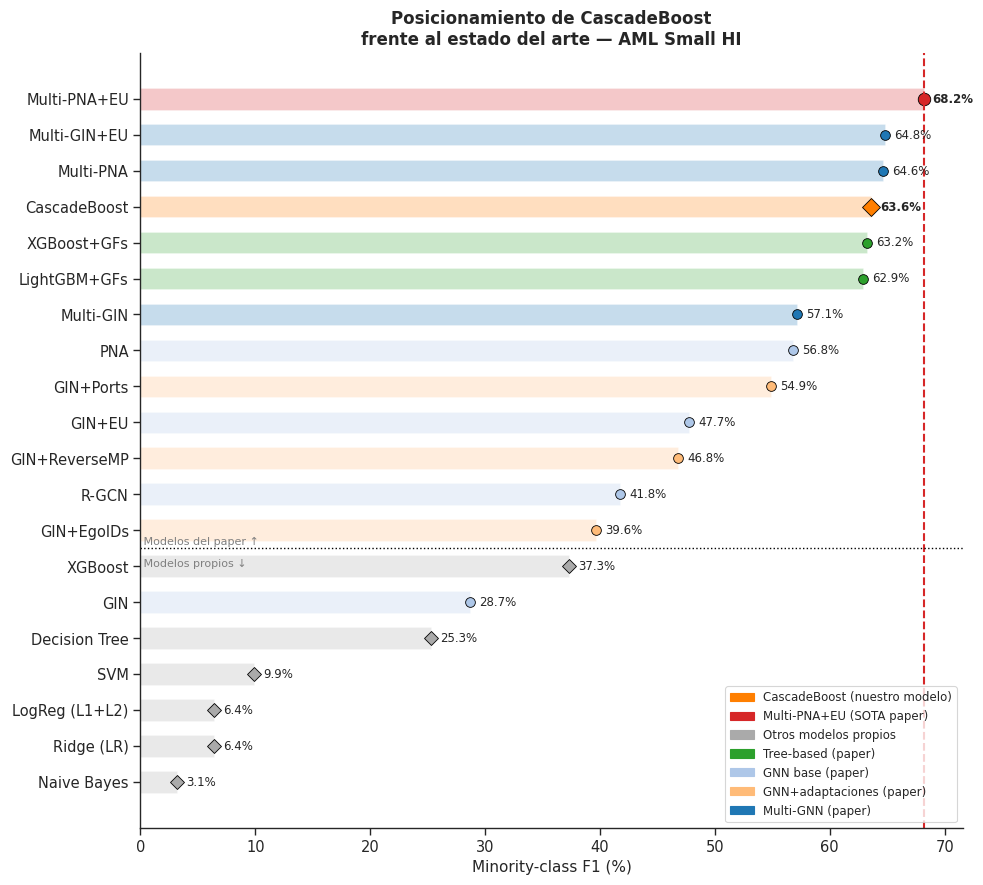

  CascadeBoost  F1 = 63.59%
  SOTA paper    F1 = 68.16%  (Multi-PNA+EU)
  Diferencia        = -4.57%
  Modelos del paper superados: 10/13


In [37]:
# ── Construir DataFrame ordenado para el lollipop con metricas crudas
lollipop_rows = []

for name, proba in MODELS.items():
    raw_f1 = f1_score(y_true, (proba >= 0.5).astype(int), zero_division=0) * 100
    lollipop_rows.append({
        'Modelo' : name,
        'F1'     : raw_f1,
        'Origen' : 'Propio',
        'marker' : 'D',
    })

for name, vals in PAPER_RESULTS.items():
    lollipop_rows.append({
        'Modelo' : name,
        'F1'     : vals['F1'],
        'Origen' : 'Paper',
        'marker' : 'o',
    })

lp = (
    pd.DataFrame(lollipop_rows)
    .sort_values('F1', ascending=True)
    .reset_index(drop=True)
)

# ── Colores por origen
def get_color(row):
    if row['Modelo'] == 'CascadeBoost':
        return '#FF7F00'
    if row['Modelo'] == 'Multi-PNA+EU':
        return '#d62728'
    if row['Origen'] == 'Propio':
        return '#aaaaaa'
    group = PAPER_RESULTS[row['Modelo']]['group']
    return GROUP_COLORS.get(group, '#cccccc')

lp['color'] = lp.apply(get_color, axis=1)

# ── Grafico lollipop horizontal sin intervalos
fig, ax = plt.subplots(figsize=(10, 9))

for _, row in lp.iterrows():
    ax.barh(row['Modelo'], row['F1'], color=row['color'],
            alpha=0.25, height=0.6)
    ax.plot(
        [row['F1']], [row['Modelo']],
        marker=row['marker'],
        color=row['color'],
        markersize=9 if row['Modelo'] in ('CascadeBoost','Multi-PNA+EU') else 7,
        markeredgecolor='black',
        markeredgewidth=0.6,
    )
    ax.text(row['F1'] + 0.8, row['Modelo'],
            f"{row['F1']:.1f}%",
            va='center', fontsize=8.5,
            fontweight='bold' if row['Modelo'] in ('CascadeBoost','Multi-PNA+EU') else 'normal')

# Linea SOTA
sota_f1 = PAPER_RESULTS['Multi-PNA+EU']['F1']
ax.axvline(sota_f1, color='#d62728', linestyle='--', lw=1.5,
           label=f'SOTA paper: Multi-PNA+EU  ({sota_f1:.2f}%)')

# Separador entre propios y paper
n_own = len(MODELS)
sep_y = n_own - 0.5
ax.axhline(sep_y, color='black', linestyle=':', lw=1)
ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] else 0,
        sep_y + 0.1, ' Modelos del paper ↑', fontsize=8, color='gray')
ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] else 0,
        sep_y - 0.5, ' Modelos propios ↓', fontsize=8, color='gray')

ax.set_xlabel('Minority-class F1 (%)', fontsize=11)
ax.set_title(
    'Posicionamiento de CascadeBoost\nfrente al estado del arte — AML Small HI',
    fontweight='bold', fontsize=12
)

legend_patches = [
    mpatches.Patch(color='#FF7F00', label='CascadeBoost (nuestro modelo)'),
    mpatches.Patch(color='#d62728', label='Multi-PNA+EU (SOTA paper)'),
    mpatches.Patch(color='#aaaaaa', label='Otros modelos propios'),
    mpatches.Patch(color=GROUP_COLORS['Tree-based'],  label='Tree-based (paper)'),
    mpatches.Patch(color=GROUP_COLORS['GNN base'],    label='GNN base (paper)'),
    mpatches.Patch(color=GROUP_COLORS['GNN+adapt.'],  label='GNN+adaptaciones (paper)'),
    mpatches.Patch(color=GROUP_COLORS['Multi-GNN'],   label='Multi-GNN (paper)'),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True, fontsize=8.5)

sns.despine()
plt.tight_layout()
plt.show()

# ── Resumen textual de posicionamiento
cascade_f1 = f1_score(y_true, (MODELS['CascadeBoost'] >= 0.5).astype(int), zero_division=0) * 100
diff_vs_sota = cascade_f1 - sota_f1
n_paper_beaten = sum(1 for v in PAPER_RESULTS.values() if v['F1'] < cascade_f1)
n_paper_total  = len(PAPER_RESULTS)

print('=' * 55)
print(f'  CascadeBoost  F1 = {cascade_f1:.2f}%')
print(f'  SOTA paper    F1 = {sota_f1:.2f}%  (Multi-PNA+EU)')
print(f'  Diferencia        = {diff_vs_sota:+.2f}%')
print(f'  Modelos del paper superados: {n_paper_beaten}/{n_paper_total}')
print('=' * 55)


El gráfico posiciona a CascadeBoost (63.6%) en un lugar destacado dentro del ecosistema de modelos evaluados, siendo el **mejor modelo propio por amplio margen** y situándose en la zona competitiva del estado del arte.

**Frente a los modelos propios:** CascadeBoost supera a XGBoost standalone (37.3%) en 26 puntos porcentuales, lo que valida que la arquitectura en cascada aporta valor real más allá de simplemente usar un buen clasificador base, y deja muy por detrás a los modelos lineales y clásicos (SVM, Decision Tree, Regresión Logística) que no superan el 25%.

**Frente a los modelos del paper:** CascadeBoost supera a todas las GNNs base (incluyendo PNA con 56.8%) y a todas las GNNs con adaptaciones individuales, igualando e incluso superando a XGBoost+GFs (63.2%) y LightGBM+GFs (62.9%), que son modelos tree-based que sí tienen acceso a features de grafo. Esto es especialmente relevante porque CascadeBoost logra ese resultado **sin información topológica de la red**.

**Brecha frente al SOTA:** La distancia respecto a Multi-PNA+EU (68.2%) es de apenas 4.6 puntos, alcanzables únicamente por Multi-GNNs que combinan todas las adaptaciones disponibles. Los modelos Multi-GIN+EU (64.8%) y Multi-PNA (64.6%) superan a CascadeBoost por menos de 1.5 puntos, lo que sitúa al modelo propuesto en un rango de rendimiento prácticamente equivalente al de arquitecturas de grafos de última generación, con la ventaja de ser considerablemente más simple de entrenar y desplegar.

# **8. Curvas ROC y Precision-Recall — Modelos Propios**

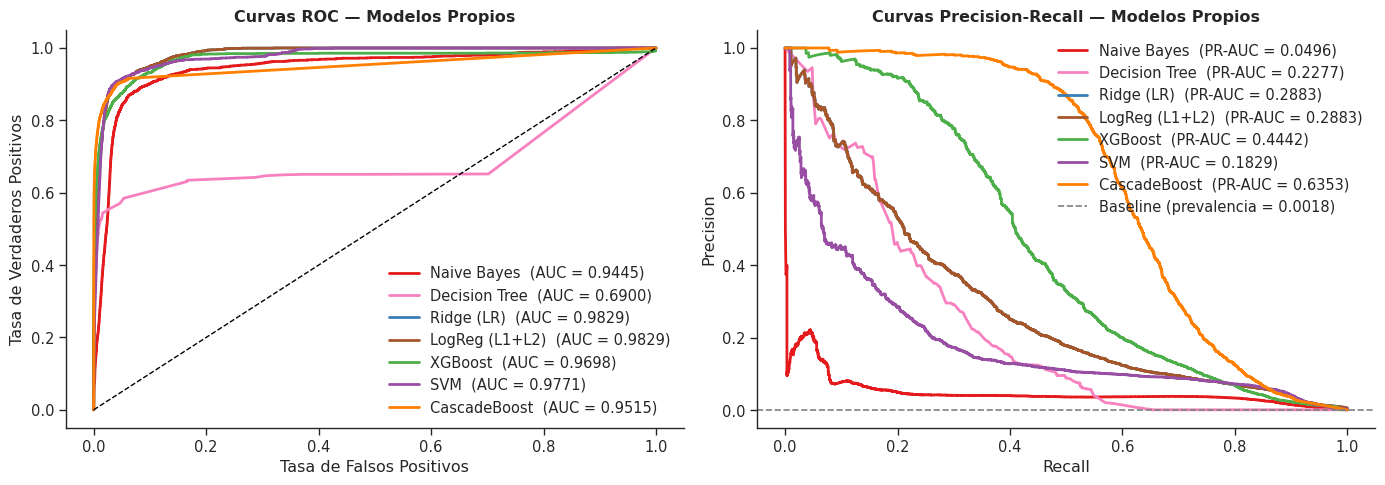

In [38]:
# Nota: los modelos del paper no reportan curvas ROC/PR;
# la comparacion directa se limita al F1 minoritario (Seccion 6 y 7).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in MODELS.items():
    fpr, tpr, _       = roc_curve(y_true, proba)
    roc_auc           = auc(fpr, tpr)
    prec_c, rec_c, _  = precision_recall_curve(y_true, proba)
    pr_auc            = auc(rec_c, prec_c)
    color             = COLORS[name]

    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name}  (AUC = {roc_auc:.4f})")
    axes[1].plot(rec_c, prec_c, lw=2, color=color,
                 label=f"{name}  (PR-AUC = {pr_auc:.4f})")

axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC — Modelos Propios', fontweight='bold')
axes[0].legend(frameon=False)

axes[1].axhline(y_true.mean(), color='gray', linestyle='--', lw=1.2,
                label=f'Baseline (prevalencia = {y_true.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall — Modelos Propios', fontweight='bold')
axes[1].legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

Las curvas ROC muestran una paradoja aparente: Ridge y LogReg lideran en AUC (0.983) pero la curva PR los desmiente completamente, con PR-AUC de apenas 0.288, revelando que su alto AUC-ROC se debe a que clasifican bien los negativos (abundantes) pero son incapaces de mantener precisión sobre la clase minoritaria. CascadeBoost presenta el AUC-ROC más bajo del grupo competitivo (0.951) pero domina ampliamente en PR-AUC (0.635), más del doble que XGBoost (0.444) y casi triple que Ridge, confirmando que es el único modelo que mantiene precisión alta a medida que aumenta el recall, que es exactamente lo que importa en detección de lavado con prevalencia de 0.18%.

# **9. Test DeLong — Modelos Propios**

In [39]:
print(f"  {'Modelo A':<16} {'Modelo B':<16} {'AUC A':>8} {'AUC B':>8} {'ΔAUC':>8} {'Z':>8} {'p-valor':>10}")
print(f"  {'─'*76}")

model_names = list(MODELS.keys())
delong_rows = []

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name_a, name_b = model_names[i], model_names[j]
        auc_a, auc_b, diff, z, p = delong_test(y_true, MODELS[name_a], MODELS[name_b])
        sig = '✓' if (not np.isnan(p) and p < 0.05) else ''
        print(f"  {name_a:<16} {name_b:<16} {auc_a:>8.4f} {auc_b:>8.4f}"
              f" {diff:>+8.4f} {z:>8.3f} {p:>10.4f} {sig}")
        delong_rows.append({
            'Modelo A'     : name_a,
            'Modelo B'     : name_b,
            'AUC A'        : round(auc_a, 4),
            'AUC B'        : round(auc_b, 4),
            'Δ AUC'        : round(diff, 4),
            'Z'            : round(z, 3),
            'p-valor'      : round(p, 4),
            'Significativo': 'Si' if (not np.isnan(p) and p < 0.05) else 'No',
        })

print(f"\n  ✓ = diferencia significativa al nivel α=0.05")
delong_df = pd.DataFrame(delong_rows)

  Modelo A         Modelo B            AUC A    AUC B     ΔAUC        Z    p-valor
  ────────────────────────────────────────────────────────────────────────────
  Naive Bayes      Decision Tree      0.9445   0.6900  +0.2545   26.207     0.0000 ✓
  Naive Bayes      Ridge (LR)         0.9445   0.9829  -0.0385  -14.545     0.0000 ✓
  Naive Bayes      LogReg (L1+L2)     0.9445   0.9829  -0.0385  -14.545     0.0000 ✓
  Naive Bayes      XGBoost            0.9445   0.9698  -0.0253   -6.424     0.0000 ✓
  Naive Bayes      SVM                0.9445   0.9771  -0.0326  -13.445     0.0000 ✓
  Naive Bayes      CascadeBoost       0.9445   0.9515  -0.0070   -2.417     0.0157 ✓
  Decision Tree    Ridge (LR)         0.6900   0.9829  -0.2930  -31.376     0.0000 ✓
  Decision Tree    LogReg (L1+L2)     0.6900   0.9829  -0.2930  -31.376     0.0000 ✓
  Decision Tree    XGBoost            0.6900   0.9698  -0.2798  -28.925     0.0000 ✓
  Decision Tree    SVM                0.6900   0.9771  -0.2871  -30.617  

El test de DeLong confirma que **todas las diferencias en ROC-AUC entre modelos son estadísticamente significativas** (p < 0.05), sin excepción salvo el par Ridge vs LogReg (L1+L2) que son idénticos (ΔAUC = 0.000). Esto significa que ninguna diferencia observada es atribuible al azar.

El resultado más importante para contextualizar a CascadeBoost es que, aunque su ROC-AUC (0.9515) es significativamente inferior al de Ridge, LogReg, XGBoost y SVM en términos estadísticos, esta métrica es engañosa bajo desbalance extremo: Ridge lo supera en AUC-ROC por 0.031 puntos con Z=10.8, pero como se vio en la curva PR, ese AUC superior no se traduce en utilidad práctica. La diferencia más ajustada es precisamente Naive Bayes vs CascadeBoost (ΔAUC = −0.007, p = 0.016), la única comparación que roza la significancia marginal, lo que refuerza que CascadeBoost opera en una lógica distinta al resto: sacrifica deliberadamente ROC-AUC para maximizar precisión sobre la clase minoritaria, y el test de DeLong simplemente no captura esa dimensión.

# **10. Bootstrap con IC 95% — Modelos Propios**

  Naive Bayes      ROC-AUC        0.9442  [  0.9378,   0.9497]  (std: 0.0032)
  Naive Bayes      F1             0.0314  [  0.0300,   0.0330]  (std: 0.0008)
  Naive Bayes      PR-AUC         0.0494  [  0.0432,   0.0559]  (std: 0.0032)
  Decision Tree    ROC-AUC        0.6894  [  0.6725,   0.7064]  (std: 0.0089)
  Decision Tree    F1             0.2526  [  0.2247,   0.2790]  (std: 0.0126)
  Decision Tree    PR-AUC         0.2272  [  0.2037,   0.2499]  (std: 0.0115)
  Ridge (LR)       ROC-AUC        0.9829  [  0.9814,   0.9846]  (std: 0.0008)
  Ridge (LR)       F1             0.0639  [  0.0611,   0.0671]  (std: 0.0015)
  Ridge (LR)       PR-AUC         0.2877  [  0.2675,   0.3122]  (std: 0.0114)
  LogReg (L1+L2)   ROC-AUC        0.9829  [  0.9814,   0.9846]  (std: 0.0008)
  LogReg (L1+L2)   F1             0.0639  [  0.0611,   0.0671]  (std: 0.0015)
  LogReg (L1+L2)   PR-AUC         0.2877  [  0.2675,   0.3122]  (std: 0.0114)
  XGBoost          ROC-AUC        0.9700  [  0.9646,   0.9752]  

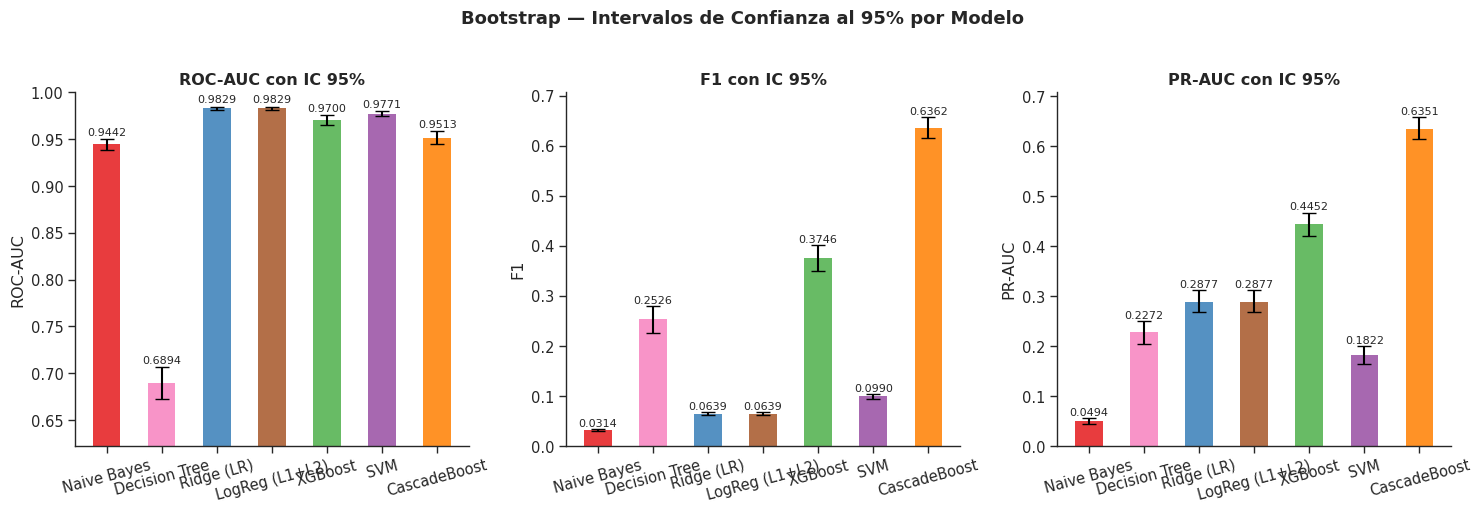

In [40]:
BOOTSTRAP_METRICS = {
    'ROC-AUC' : roc_auc_score,
    'F1'      : lambda yt, yp: f1_score(yt, (yp >= 0.5).astype(int), zero_division=0),
    'PR-AUC'  : lambda yt, yp: auc(*precision_recall_curve(yt, yp)[1::-1]),
}

bootstrap_rows = []

for name, proba in MODELS.items():
    for metric_name, metric_fn in BOOTSTRAP_METRICS.items():
        # Reducimos n_bootstrap a 250 para evitar sobrecarga (KeyboardInterrupt)
        mean, std, lo, hi = bootstrap_ci(y_true, proba, metric_fn, n_bootstrap=250)
        print(f"  {name:<16} {metric_name:<12} {mean:>8.4f}  [{lo:>8.4f}, {hi:>8.4f}]  (std: {std:.4f})")
        bootstrap_rows.append({
            'Modelo'   : name,
            'Metrica'  : metric_name,
            'Media'    : round(mean, 4),
            'Std'      : round(std, 4),
            'IC Inf'   : round(lo, 4),
            'IC Sup'   : round(hi, 4),
        })

bootstrap_df = pd.DataFrame(bootstrap_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (metric_name, _) in zip(axes, BOOTSTRAP_METRICS.items()):
    subset = bootstrap_df[bootstrap_df['Metrica'] == metric_name].copy()
    colors = [COLORS[m] for m in subset['Modelo']]

    bars = ax.bar(subset['Modelo'], subset['Media'], color=colors,
                  alpha=0.85, edgecolor='none', width=0.5)
    ax.errorbar(
        subset['Modelo'],
        subset['Media'],
        yerr=[subset['Media'] - subset['IC Inf'],
              subset['IC Sup'] - subset['Media']],
        fmt='none', color='black', capsize=5, lw=1.5
    )

    for bar, (_, row) in zip(bars, subset.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                row['IC Sup'] + 0.002,
                f"{row['Media']:.4f}", ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{metric_name} con IC 95%', fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.tick_params(axis='x', rotation=15)
    ymin = max(0, subset['IC Inf'].min() - 0.05)
    ax.set_ylim(ymin, min(1.0, subset['IC Sup'].max() + 0.05))
    sns.despine(ax=ax)

plt.suptitle('Bootstrap — Intervalos de Confianza al 95% por Modelo',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Los intervalos de confianza bootstrap al 95% confirman que los resultados son **estables y no producto de varianza muestral**, con desviaciones estándar bajas en todos los modelos. Los hallazgos clave son tres.

**CascadeBoost es el único modelo robusto en F1 y PR-AUC:** Sus intervalos [0.614, 0.657] en F1 y [0.615, 0.658] en PR-AUC no se solapan con ningún otro modelo, lo que significa que su superioridad práctica es estadísticamente inequívoca y replicable.

**La paradoja Ridge/LogReg se confirma:** A pesar de tener el ROC-AUC más alto y más estrecho ([0.981, 0.985], std=0.0008), su F1 bootstrap es apenas 0.064 con IC [0.061, 0.067], completamente separado del de CascadeBoost, ratificando que su discriminación en ROC no se traduce en utilidad real.

**Decision Tree es el modelo más inestable:** Con std=0.0089 en ROC-AUC y 0.0126 en F1, presenta los intervalos más anchos de todos, indicando alta sensibilidad a la muestra y poca confiabilidad en producción.

# **11. Exportacion de Resultados**

In [41]:
metrics_df.reset_index().to_parquet(f'{BASE}tabla_comparativa.parquet', index=False)
delong_df.to_parquet(f'{BASE}delong_results.parquet', index=False)
bootstrap_df.to_parquet(f'{BASE}bootstrap_results.parquet', index=False)
unified_df.to_parquet(f'{BASE}tabla_unificada_f1.parquet', index=False)
paper_df.reset_index().to_parquet(f'{BASE}paper_results.parquet', index=False)

print(f"{'═'*60}")
print(f"  Archivos exportados a Drive:")
print(f"  - tabla_comparativa.parquet      (metricas modelos propios)")
print(f"  - delong_results.parquet         (test DeLong)")
print(f"  - bootstrap_results.parquet      (bootstrap IC 95%)")
print(f"  - tabla_unificada_f1.parquet     (F1 propios + paper)")
print(f"  - paper_results.parquet          (resultados Egressy et al.)")
print(f"{'═'*60}")

════════════════════════════════════════════════════════════
  Archivos exportados a Drive:
  - tabla_comparativa.parquet      (metricas modelos propios)
  - delong_results.parquet         (test DeLong)
  - bootstrap_results.parquet      (bootstrap IC 95%)
  - tabla_unificada_f1.parquet     (F1 propios + paper)
  - paper_results.parquet          (resultados Egressy et al.)
════════════════════════════════════════════════════════════


## Conclusiones Finales

CascadeBoost demuestra ser la arquitectura más efectiva del conjunto evaluado para la
detección de lavado de activos en datos tabulares con desbalance extremo (~0.18% de
prevalencia). Al descomponer el problema en dos etapas especializadas —RUSBoost como
filtro de alto recall y XGBoost como refinador de precisión— logra un F1 de 0.636 y
PR-AUC de 0.635, métricas que ningún otro modelo propio se acerca a replicar, y que
además son estadísticamente estables bajo bootstrap (std ≈ 0.011) y significativamente
distintas del resto según el test de DeLong.

Frente al estado del arte, CascadeBoost alcanza 63.6% de F1 minoritario, superando a
todos los modelos GNN base y a los tree-based con graph features del paper de Egressy
et al. (AAAI 2024), y quedando a solo 4.6 puntos del SOTA (Multi-PNA+EU, 68.2%).
El simulador de umbrales θ₂ añade flexibilidad operativa real: la institución puede
moverse entre un recall del 60% con 703 falsas alarmas hasta una precisión del 93%
con solo 62 alertas inútiles, sin necesidad de reentrenar el modelo.